In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="wfmphW3AE1B8EAol7aWD")
project = rf.workspace("gilberts-workspace-fw6qa").project("mushroom-3-0")
version = project.version(16)
dataset = version.download("yolov8")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 260.3/260.3 kB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 50.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 82.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 141.3 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.18
    Uninstalling idna-3.18:
      Successfully uninstalled idna-3.18
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
httpx2 2.4.0 requires idna>=3.18, but you have idna 3.7 which i


Extracting Dataset Version Zip to Mushroom-3.0-16 in yolov8:: 100%|██████████| 4685/4685 [00:00<00:00, 7661.71it/s]


In [ ]:
!pip install ultralytics
from ultralytics import YOLO
import os

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 75.7 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
model = YOLO('yolov8n.pt')
results = model.train(
    data='/content/Mushroom-3.0-16/data.yaml',
    epochs=100,
    imgsz=640,
    batch=16,
    device=0,
    name='yolov8_mushroom_fresh',
    save=True,
    plots=True
)

Ultralytics 8.4.71 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Mushroom-3.0-16/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8_mushroom_fresh, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask

In [ ]:
import shutil
import os
source_dir = '/content/runs/detect/yolov8_mushroom_fresh'
destination_dir = '/content/drive/MyDrive/Train_Yolo_v13/yolov8_mushroom_fresh'
if not os.path.exists('/content/drive/MyDrive/Train_Yolo_v13'):
    os.makedirs('/content/drive/MyDrive/Train_Yolo_v13')
    print("Folder 'Train_Yolo_v4' baru saja dibuat.")

if os.path.exists(source_dir):
    try:
        if os.path.exists(destination_dir):
            print("Folder lama terdeteksi di Drive, menghapus versi usang...")
            shutil.rmtree(destination_dir)

        print(f"Sedang menyalin seluruh aset dari {source_dir} ke Google Drive...")
        shutil.copytree(source_dir, destination_dir)

        print("\n==================================================")
        print(" BERHASIL! SEMUA HASIL TRAINING AMAN DI DRIVE")
        print("==================================================")
        print(f"Lokasi penyimpanan: {destination_dir}")
        print("Silakan cek komponen berkas berikut di Drive abang:")
        print("  - weights/best.pt  (Bobot model terbaik)")
        print("  - weights/last.pt  (Bobot model terakhir)")
        print("  - results.png      (Grafik performa training)")
        print("  - confusion_matrix.png")

    except Exception as e:
        print(f"❌ Gagal menyalin berkas. Error: {e}")
else:
    print(f"❌ Error: Folder sumber '{source_dir}' tidak ditemukan di lokal Colab.")
    print("Pastikan runtime belum terputus atau ter-reset.")

Folder 'Train_Yolo_v4' baru saja dibuat.
Sedang menyalin seluruh aset dari /content/runs/detect/yolov8_mushroom_fresh ke Google Drive...

 BERHASIL! SEMUA HASIL TRAINING AMAN DI DRIVE
Lokasi penyimpanan: /content/drive/MyDrive/Train_Yolo_v13/yolov8_mushroom_fresh
Silakan cek komponen berkas berikut di Drive abang:
  - weights/best.pt  (Bobot model terbaik)
  - weights/last.pt  (Bobot model terakhir)
  - results.png      (Grafik performa training)
  - confusion_matrix.png


>>> Memulai prediksi pada 12 gambar...


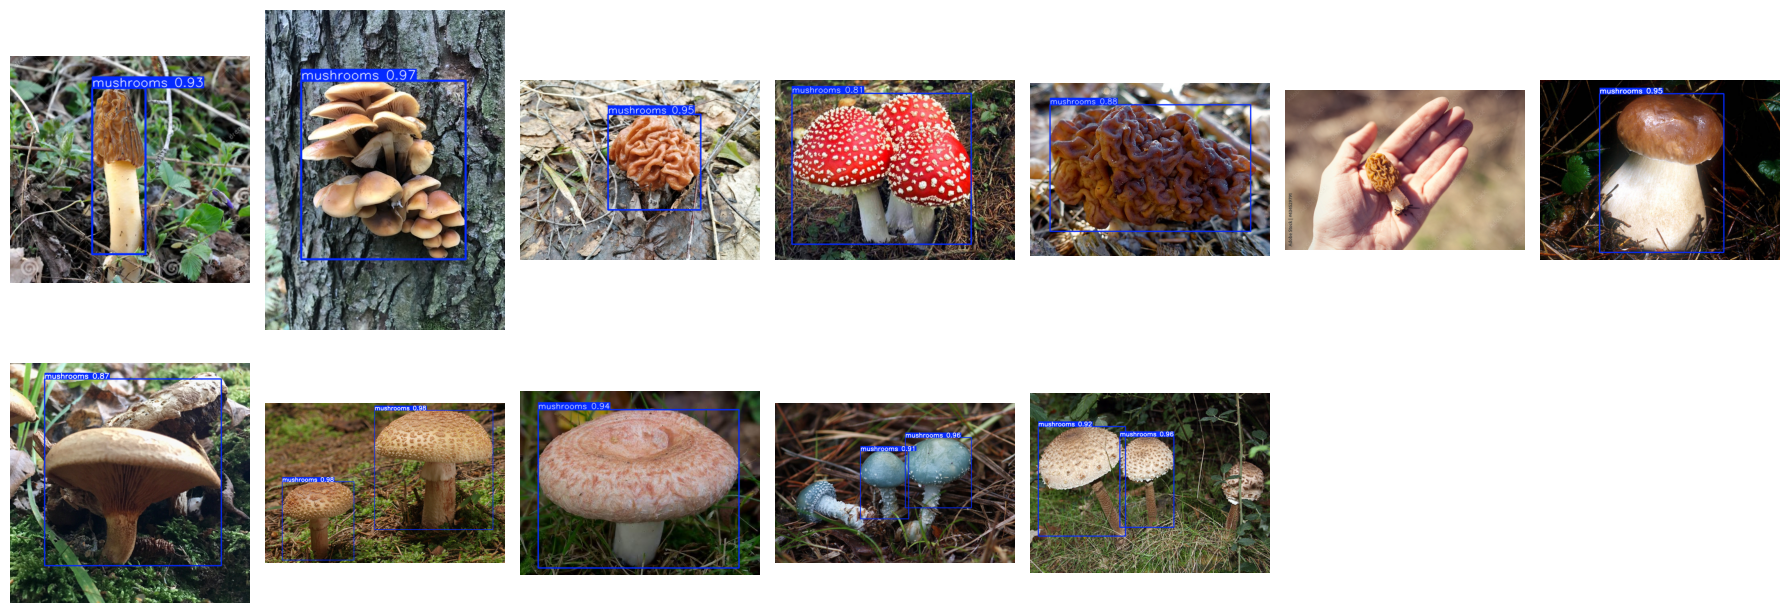

>>> Proses pengujian gambar selesai!


In [ ]:
import os
from ultralytics import YOLO
import matplotlib.pyplot as plt
from PIL import Image

model_path = '/content/drive/MyDrive/Train_Yolo_v13/yolov8_mushroom_fresh/weights/best.pt'
contoh_path = '/content/drive/MyDrive/Contoh Gambar Jamur'

model = YOLO(model_path)
all_image_paths = []
for root, dirs, files_in_dir in os.walk(contoh_path):
    for file in files_in_dir:
        if file.lower().endswith(('png', 'jpg', 'jpeg')):
            all_image_paths.append(os.path.join(root, file))
images_to_predict = all_image_paths[:12]
plt.figure(figsize=(18, 7))

print(f">>> Memulai prediksi pada {len(images_to_predict)} gambar...")

for i, img_path in enumerate(images_to_predict):
    results = model.predict(
        source=img_path,
        conf=0.7,
        iou=0.3,
        agnostic_nms=True,
        imgsz=640,
        save=False,    
        verbose=False  
    )

    r = results[0]

    im_array = r.plot()

    im_rgb = Image.fromarray(im_array[..., ::-1])

    plt.subplot(2, 7, i + 1)
    plt.imshow(im_rgb)

    filename = os.path.basename(img_path)
    plt.title(filename[:15] + '...', fontsize=9)

    plt.axis('off')

plt.tight_layout()
plt.show()
print(">>> Proses pengujian gambar selesai!")